### Importación de datos



In [ ]:
#importar librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint

#Cargamos de datos de las tiendas en csv que se encuentran en github

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

#Leemos los datos de las tiendas usando Pandas

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

#Listar la primera parte de los datos de la tienda 1. Diferentes formas de ver los datos
#tienda1.head()

#tienda1.info()
#tienda1.describe()

#1. Análisis de facturación



In [ ]:
sucursales = [tienda1, tienda2, tienda3, tienda4]
for suc in sucursales:
  pass
  #print(suc.columns)
  #print(suc.columns)
#print(type(tienda1))

In [ ]:
#print(type(tienda))
nombres = ['tienda1', 'tienda2', 'tienda3', 'tienda4']
sucursales = [tienda1, tienda2, tienda3, tienda4]
def billing(tienda):
  totalVentas = float(tienda['Precio'].astype(float).sum() - tienda['Costo de envío'].astype(float).sum())
  #Dependería si el costo de envio lo paga el cliente o la empresa.
  return totalVentas

#facTiendas = [billing(tienda1), billing(tienda2), billing(tienda3), billing(tienda4)]
facTiendas=[billing(t) for t in sucursales]
facTotal = sum(facTiendas)

#Es más lineas si lo pongo de esta forma con una lista y luego agrego con el append
porcentajes = []
for p in facTiendas:
  porc = round((p/facTotal)*100,2)
  porcentajes.append(porc)
#En una sola linea con una comprensión de listas. Así es más directo
porc = [round((p/facTotal)*100, 2) for p in facTiendas]

#Concatenar listas con un loop convencional
facturacion = list(zip(nombres, facTiendas, porc))
#print(facturacion)

for i in range(len(facturacion)):
  mensaje = f'''La facturación de la {facturacion[i][0]} es de ${facturacion[i][1]}, con un porcentaje de {facturacion[i][2]}'''
# Más directo
#for t, f, p in facturacion: print(f'La facturación de la {t} es de ${f}, con un porcentaje de {p}')

#Crear un dataFrame. Toma mi lista de listas y un argumento colums =
#para definir el nombre de cada columna.
df_fac = pd.DataFrame(facturacion, columns = ['Sucursal', 'Facturación', 'Porcentaje'])
print('\n',df_fac, '\n')



   Sucursal   Facturación  Porcentaje
0  tienda1  1.089502e+09       26.13
1  tienda2  1.056858e+09       25.35
2  tienda3  1.039503e+09       24.93
3  tienda4  9.830583e+08       23.58 



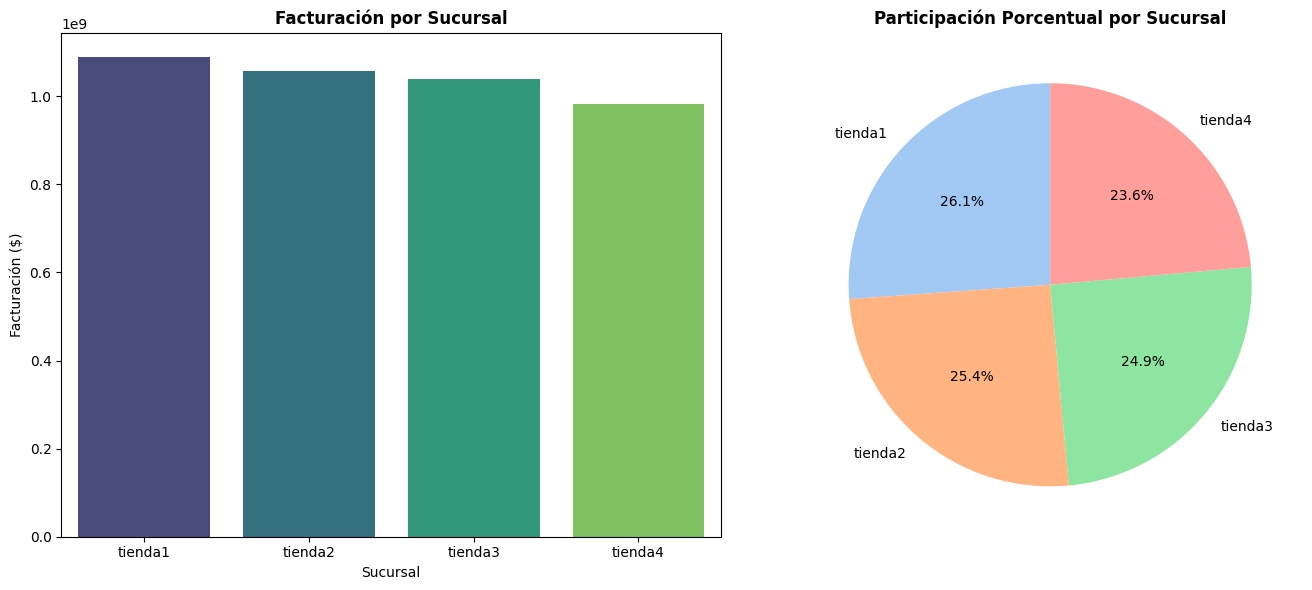

In [ ]:
#GRAFICO

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))  # 1 fila, 2 columnas
sns.barplot(x='Sucursal', y='Facturación', hue='Sucursal',data=df_fac, palette='viridis', ax=ax1)
ax1.set_title('Facturación por Sucursal', weight='bold')
ax1.set_xlabel('Sucursal')
ax1.set_ylabel('Facturación ($)')
ax2.pie(porc, labels=nombres, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
ax2.set_title('Participación Porcentual por Sucursal', weight='bold')
plt.tight_layout()
plt.show()

# 2. Ventas por categoría

In [ ]:
categoria = sorted(list(set(tienda1['Categoría del Producto'])))
#pprint(categoria)
tupla = sorted(list(zip(tienda1['Categoría del Producto'], tienda1['Precio'])))
#print(tupla)
#pprint(tupla)
sumaXtienda = sum(tienda1['Precio'])
popularCat = [sum(1 for cat, _ in tupla if cat==c) for c in categoria]
#pprint(popularCat)
cont = zip(categoria, popularCat)
df_cont = pd.DataFrame(cont, columns = ['Categoría', 'Cantidad'])
#print('\n',df_cont,'\n')
valXcat = []
for cat in categoria:
  listaXCat = []
  for c, p in tupla:
    if c == cat:
      listaXCat.append(p)
  #valXcat.append(round((sum(listaXCat)/sumaXtienda)*100,2))
  valXcat.append(sum(listaXCat))
#print(valXcat)
revenueXcat = [sum([precio for cat, precio in tupla if cat==c]) for c in categoria]
#print(revenueXcat)
from collections import Counter
#Counter(tienda4['Categoría del Producto'])

def test(): #SOLO PARA PRUEBAS
  categoria = sorted(list(set(tienda1['Categoría del Producto'])))
  tupla = sorted(list(zip(tienda1['Categoría del Producto'], tienda1['Precio'])))
  sumaXtienda = sum(tienda1['Precio'])
  popularCat = [sum(1 for cat, _ in tupla if cat==c) for c in categoria]
  #print(popularCat)
  cont = zip(categoria, popularCat)
  df_cont = pd.DataFrame(cont, columns = ['Categoría', 'Cantidad'])
  #print('\n',df_cont,'\n')
  valXcat = []
  for cat in categoria:
    listaXCat = []
    for c, p in tupla:
      if c == cat:
        listaXCat.append(p)
    valXcat.append(round((sum(listaXCat)/sumaXtienda)*100,2))
    #print(valXcat)



#LOGICA REAL


nombres = ['tienda1', 'tienda2', 'tienda3', 'tienda4']
sucursales = [tienda1, tienda2, tienda3, tienda4]

def ventasXcat(sucursal):
  sucursal = sucursal.copy()
  sucursal['Categoría del Producto'] = sucursal['Categoría del Producto'].str.strip().str.lower()

  categorias = sorted(list(set(sucursal['Categoría del Producto'])))
  valores_totales = list(zip(sucursal['Categoría del Producto'], sucursal['Precio'], sucursal['Costo de envío']))

  revenueXtienda = float(sucursal['Precio'].astype(float).sum() - sucursal['Costo de envío'].astype(float).sum()) #Para porcentaje
  revenueXcat = [sum([precio - costo for cat, precio, costo in valores_totales if cat==c]) for c in categorias]
  cantidadXcat = [sum(1 for cat, *_ in valores_totales if cat==c) for c in categorias]

  porcXcat = [round((p/revenueXtienda)*100, 2) for p in revenueXcat]
  return categorias, revenueXcat, cantidadXcat, porcXcat


sellXcat=[ventasXcat(t) for t in sucursales]
#pprint(sellXcat)
cat, revXcat, cant, porc = sellXcat[0]
#pprint(list(zip(cat, revXcat, cant, porc)))


listaVentas = []
for nombre, (categorias, revenue, cantidad, porc) in zip(nombres, sellXcat):
    df_ventasXCat = pd.DataFrame(list(zip(categorias, revenue, cantidad, porc)), columns=['Categoría','Ganancia','Cantidad','Porcentaje'])
    df_ventasXCat['Sucursal'] = nombre
    listaVentas.append(df_ventasXCat)

#print(listaVentas)
df_final = pd.concat(listaVentas)
print(df_final,'\n')

                 Categoría     Ganancia  Cantidad  Porcentaje Sucursal
0  artículos para el hogar   12054600.0       171        1.11  tienda1
1     deportes y diversión   37168900.0       284        3.41  tienda1
2        electrodomésticos  344361200.0       312       31.61  tienda1
3             electrónicos  406529800.0       448       37.31  tienda1
4   instrumentos musicales   86415100.0       182        7.93  tienda1
5                 juguetes   17016200.0       324        1.56  tienda1
6                   libros    8317900.0       173        0.76  tienda1
7                  muebles  177638800.0       465       16.30  tienda1
0  artículos para el hogar   13946100.0       181        1.32  tienda2
1     deportes y diversión   32867200.0       275        3.11  tienda2
2        electrodomésticos  330012200.0       305       31.23  tienda2
3             electrónicos  389016900.0       422       36.81  tienda2
4   instrumentos musicales   99432600.0       224        9.41  tienda2
5     

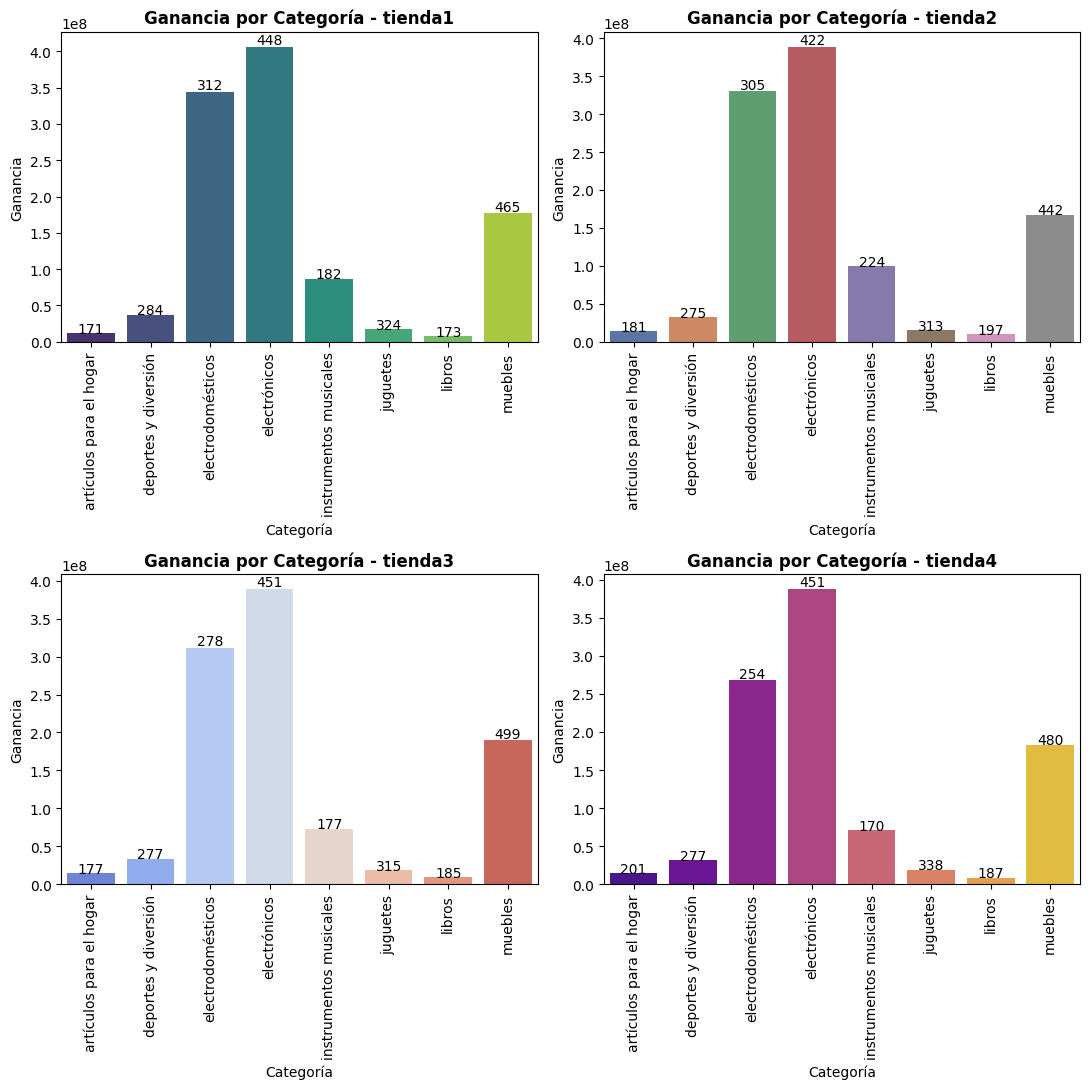

In [ ]:
#GRAFICO BARRAS ventas por categoria
paletas = ['viridis', 'deep', 'coolwarm', 'plasma']
fig, axes = plt.subplots(2, 2, figsize=(11, 11))
axes = axes.flatten()
#for i, (nombre, (categorias, revenueXcat, cantidadXcat, porcXcat)) in enumerate(zip(nombres, sellXcat)):
 #   ax = axes[i]
 #   bars = ax.bar(categorias, revenueXcat, color=sns.color_palette('viridis', len(categorias)))
 #   ax.set_title(f'Ventas por categoría - {nombre}', weight='bold')
 #   ax.set_xlabel('Categoría')
 #   ax.set_ylabel('Ganancia ($)')
 #   for bar, porc in zip(bars, porcXcat):
 #       ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10, f'{porc}%', ha='center', va='bottom', fontsize=9)
for i, nombre in enumerate(nombres):
    df_tienda = df_final[df_final['Sucursal'] == nombre]
    ax = axes[i]
    bars = sns.barplot(x='Categoría', y='Ganancia', hue='Categoría', data=df_tienda, palette=paletas[i],ax=ax)
    ax.set_title(f'Ganancia por Categoría - {nombre}', weight='bold')
    ax.tick_params(axis='x', rotation=90)
    #print(df_tienda)
    for bar, cantidad in zip(bars.patches, df_tienda['Cantidad']):
      ax.text(
          bar.get_x() + bar.get_width() / 2,
          bar.get_height() * 1.01,
          cantidad,
          ha='center'
      )
plt.tight_layout()
plt.show()

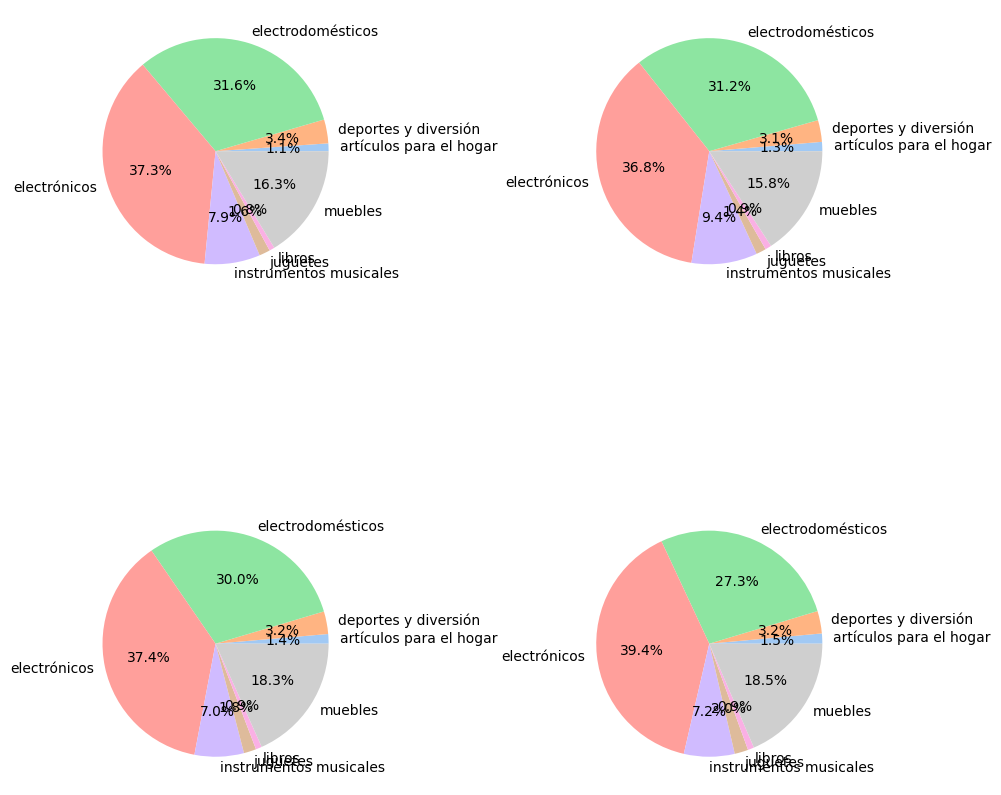

In [ ]:
#PASTEL
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
for i, nombre in enumerate(nombres):
    df_tienda = df_final[df_final['Sucursal'] == nombre]
    ax = axes[i]
    ax.pie(df_tienda['Porcentaje'], labels=df_tienda['Categoría'], autopct='%1.1f%%',colors=sns.color_palette('pastel'))
plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


In [ ]:
#print(type(tienda))
nombres = ['tienda1', 'tienda2', 'tienda3', 'tienda4']
sucursales = [tienda1, tienda2, tienda3, tienda4]


#Formas de FUNCIONES
def cal_promedio(tienda):
  cal = tienda['Calificación'].astype(float).dropna()
  promedio = round(cal.sum() / len(cal), 2)
  return promedio
def calificacion_promedio(store):
  return np.round(store['Calificación'].mean(), 2)


#Formas de ALMACENAR
promedio = {nombre: cal_promedio(suc) for nombre, suc in zip(nombres,sucursales)}
#print(promedio)
promediar = [cal_promedio(suc) for suc in sucursales]
concatenar = list(zip(nombres, promediar))
#print(concatenar)
calificaciones_promedio = []
for nombre, sucursal in zip(nombres, sucursales):
  avg_rating = cal_promedio(sucursal)
  calificaciones_promedio.append({'Sucursal': nombre, 'Calificación Promedio': avg_rating})
#print(calificaciones_promedio)


#DATA FRAMES
df_promedio = pd.DataFrame(concatenar, columns=['Sucursal', 'Calificación Promedio'])
print(df_promedio)
df_promDic = pd.DataFrame(promedio.items(), columns=['Sucursal', 'Calificación Promedio'])
print(df_promDic)
df_dicProm = pd.DataFrame.from_dict(promedio, orient='index', columns=['Calificación Promedio'])
#print(df_dicProm)

  Sucursal  Calificación Promedio
0  tienda1                   3.98
1  tienda2                   4.04
2  tienda3                   4.05
3  tienda4                   4.00
  Sucursal  Calificación Promedio
0  tienda1                   3.98
1  tienda2                   4.04
2  tienda3                   4.05
3  tienda4                   4.00


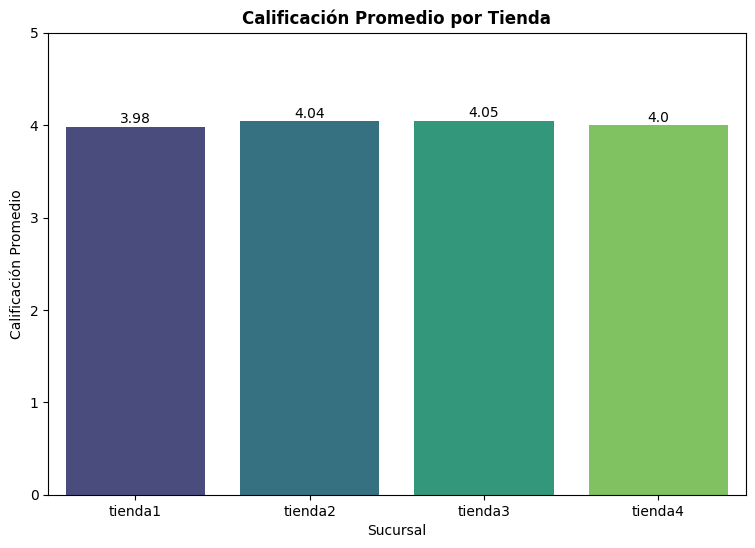

In [ ]:
#GRAFICO
plt.figure(figsize=(9, 6))
ax=plt.gca()
barras = sns.barplot(x='Sucursal', y='Calificación Promedio', hue='Sucursal', data=df_promDic, palette='viridis')
for bar, cal in zip(barras.patches, df_promDic['Calificación Promedio']):
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height() * 1.01,
      cal,
      ha='center')
plt.title('Calificación Promedio por Tienda', weight='bold')
plt.xlabel('Sucursal')
plt.ylabel('Calificación Promedio')
plt.ylim(0, 5)
plt.show()

# 4. Productos más y menos vendidos

In [ ]:
#tienda1.info()
#tienda1.describe()
#print(tienda1.columns)
#tienda1.tail()
nombres = ['tienda1', 'tienda2', 'tienda3', 'tienda4']
sucursales = [tienda1, tienda2, tienda3, tienda4]


def mas_menos_Vendidos(tienda):
  productosUnicos = sorted(list(set(tienda['Producto'])))
  proTotales = list(tienda['Producto'])
  cantidadXproducto = [sum(1 for pt in proTotales if pt==pu) for pu in productosUnicos]
  merge = list(zip(productosUnicos, cantidadXproducto))
  mx = max(merge, key=lambda x: x[1])
  mn = min(merge, key=lambda x: x[1])
  #Forma 2
  cantXprod = []
  for p in productosUnicos:
    cantXprod.append(sum(1 for pr in proTotales if pr==p))
  #Forma 3
  for u in productosUnicos:
    contador = 0
    for p in proTotales:
      if p == u:
        contador += 1
    cantXprod.append(contador)
    return mx, mn

#print(mas_menos_Vendidos(tienda1))
productos = [mas_menos_Vendidos(p) for p in sucursales]



#pprint(productos)
filas = []
for nombre, (mx, mn) in zip(nombres, productos):
  filas.append([nombre, mx[0], mx[1], 'Mas Vendido'])
  filas.append([nombre, mn[0], mn[1], 'Menos Vendido'])


#pprint(filas)
df_filas = pd.DataFrame(filas, columns=['Sucursal', 'Producto', 'Cantidad', 'Tipo'])
print(df_filas)

# Comprension de lista antes de hacer las dos filas por sucursal
fill = [[nombre, mx[0], mx[1], mn[0], mn[1]] for nombre, (mx, mn) in zip(nombres, productos)]

#pprint(fill)
#df_fill = pd.DataFrame(fill, columns=['Sucursal', 'P_MX', 'C_MX', 'P_MIN', 'C_MIN'])
#print(df_fill)

#df_productos = pd.DataFrame(filas, columns=['Sucursal', 'Producto Más Vendido', 'Cantidad', 'Producto Menos Vendido', 'Cantidad'])
#print(df_productos)



  Sucursal                   Producto  Cantidad           Tipo
0  tienda1                    Armario        60    Mas Vendido
1  tienda1  Auriculares con micrófono        33  Menos Vendido
2  tienda2  Iniciando en programación        65    Mas Vendido
3  tienda2              Juego de mesa        32  Menos Vendido
4  tienda3              Kit de bancas        57    Mas Vendido
5  tienda3    Bloques de construcción        35  Menos Vendido
6  tienda4                   Cama box        62    Mas Vendido
7  tienda4         Guitarra eléctrica        33  Menos Vendido


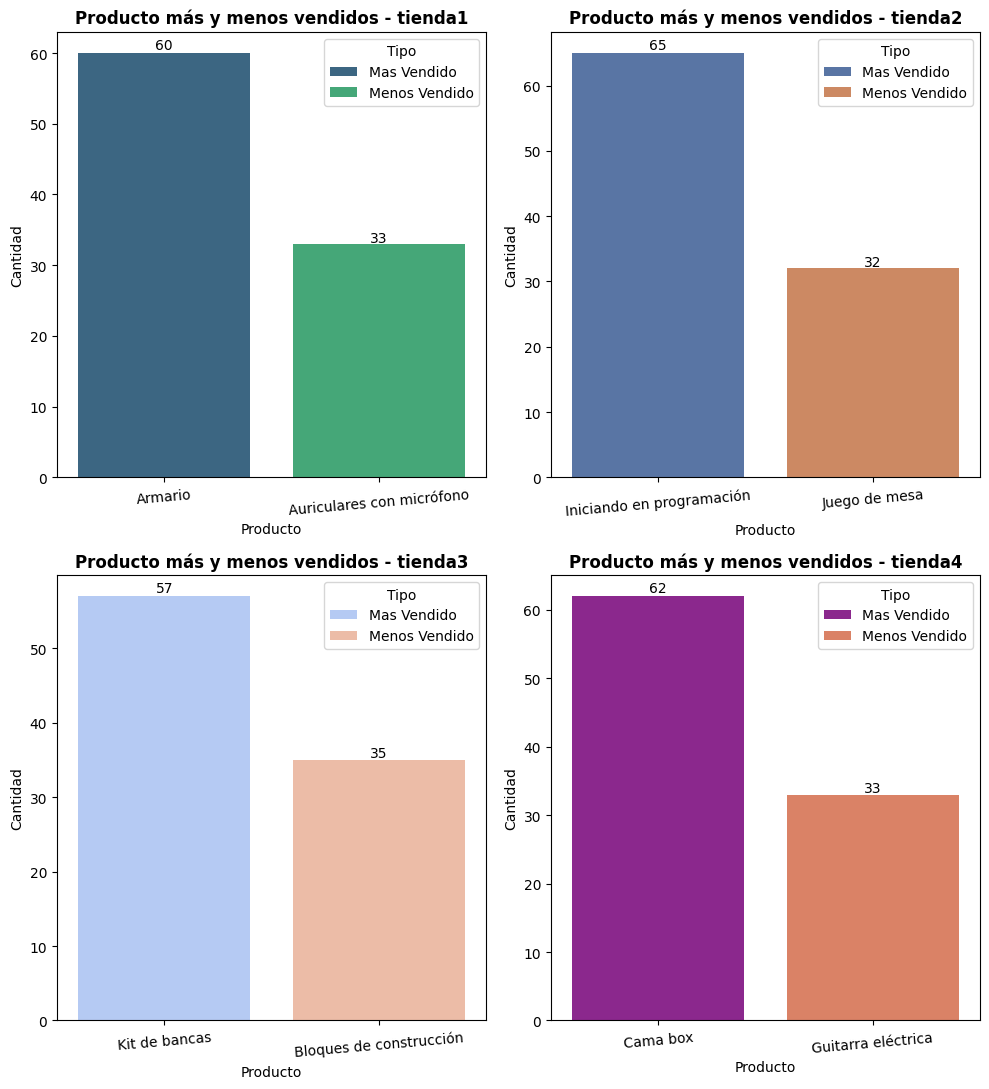

In [ ]:
#GRAFICO BARRAS

palete = ['viridis', 'deep', 'coolwarm', 'plasma']
fig, axes = plt.subplots(2, 2, figsize=(10, 11))
axes = axes.flatten()
for i, nombre in enumerate(nombres):
  figura = df_filas[df_filas['Sucursal'] == nombre]
  ax = axes[i]
  bars = sns.barplot(x='Producto', y='Cantidad', hue='Tipo', data=figura, palette=palete[i],ax=ax)
  ax.set_title(f'Producto más y menos vendidos - {nombre}', weight='bold')
  ax.tick_params(axis='x', rotation=5)
  for bar, cantidad in zip(bars.patches, figura['Cantidad']):
      ax.text(
          bar.get_x() + bar.get_width() / 2,
          bar.get_height() * 1.01,
          cantidad,
          ha='center'
          )

plt.tight_layout()
plt.show()


# 5. Envío promedio por tienda

In [ ]:
#tienda1.info()
#tienda1.describe()
#tienda1.head()
#print(tienda1.columns)

nombres = ['tienda1', 'tienda2', 'tienda3', 'tienda4']
sucursales = [tienda1, tienda2, tienda3, tienda4]

#TEST
promedioCosto = tienda1['Costo de envío'].astype(float).sum()/len(tienda1['Costo de envío'].astype(float))

def costo_promedio(store):
  store = store.copy()
  promedio = round(float(store['Costo de envío'].astype(float).mean()),2)
  return promedio

costoPromedio=[costo_promedio(t) for t in sucursales]
#print(costoPromedio)

mg = list(zip(nombres, costoPromedio))
#print(mg,'\n')

df_costoPromedio = pd.DataFrame(list(zip(nombres, costoPromedio)), columns=['Sucursal', 'Costo Promedio'])
#print(df_costoPromedio)

tienda1.head()


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


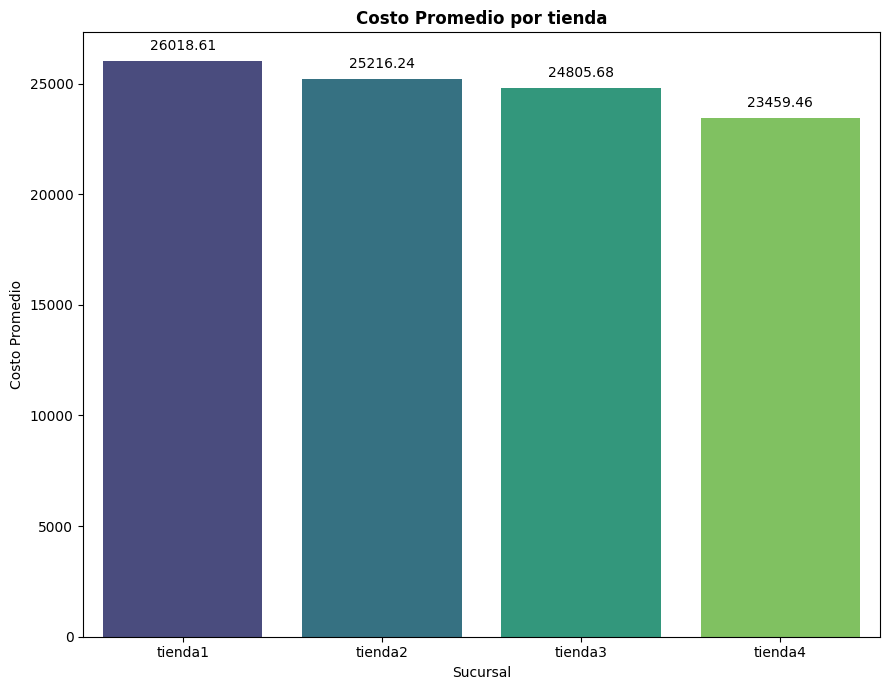

In [ ]:
#GRAFICO

fig, ax = plt.subplots(figsize=(9,7))

gbrrs = sns.barplot(x='Sucursal', y='Costo Promedio', hue='Sucursal', data = df_costoPromedio, palette='viridis')
for bar, costo in zip(gbrrs.patches, df_costoPromedio['Costo Promedio']):
  ax.text(
      bar.get_x() + bar.get_width()/2,
      bar.get_height()*1.02,
      costo,
      ha='center'
  )

plt.title('Costo Promedio por tienda', weight = 'bold')
plt.xlabel('Sucursal')
plt.ylabel('Costo Promedio')
plt.tight_layout()
#plt.ylim(0, 6)
plt.show()


In [ ]:
#Facturación total:

pc = 3183.34

#La tienda uno cuenta con una facturación total de:
t1 = 1_089_502_000 #millones de pesos colombianos
print(f"{t1/pc:.2f} dólares.")

#La tienda dos, cuneta con una facturación total de:
t2 = 1_056_858_000 #millones de pesos colombianos.
print(f"{t2/pc:.2f} dólares.")

#la tienda tres, cuenta con una facturación total de:
t3 = 1_039_503_000 #millones de pesos colombianos.
print(f"{t3/pc:.2f} dólares.")

#la tienta cuatro, cuenta con una facturación total de:
t4 = 9_830_583_00 #millones de pesos colombianos.
print(f"{t4/pc:.2f} dólares.")

#Teniendo un mejor rendimiento la tienda 1 con 342,251.22 dólares.


#Ventas por categoría:

#print(df_final)

g = 12054600.0+37168900.0+344361200.0+406529800.0+86415100.0+17016200.0+8317900.0+177638800.0
print(f"{g/pc:.2f} dólares.")

# En las 4 tiendas, los productos más vendidos, es la categoría de muebles con un promedio de 471 unidades.
tl = (465, 442, 499, 480)
print(f"{sum(tl)/len(tl):.2f} Promedio")

#Sin embargo, la categoría de electrónicos es la más valiosas en cuanto a costos, seguido de electrodomésticos.


#Calificación por tienda

# La tienda mejor calificada es la tienda 3 con 4.05, seguido de la tienda 2 con 4.04, 4 con 4.00, 1 con 3.98

df_cali = df_promedio.sort_values(by='Calificación Promedio', ascending=False)
#print(df_cali)
#df_promDic



# Producto más y menos vendido

df_filas

# Producto más vendido de la Tienda 1 es el Armario con 60 unidades, y la menos vendida son los Auriculares con micrófono con 33 unidades.
# Producto más vendido de la tineda 2 es Iniciando en programación con 65 unidades y la menos vendida es el juego de mesa con 32.
# Producto más vendido de la tineda 3 es el kit de bancas con 57 unidades. La menos vendida es Bosques de Construcción con 35 unidades.
# Producto más vendido de la tienda 4 es la Cama de Box con 62 unidades. La menos vendida es la guitarra eléctrica con 33 unidades.



342251.22 dólares.
331996.58 dólares.
326544.76 dólares.
308813.48 dólares.
342251.38 dólares.
471.50 Promedio


,Sucursal,Producto,Cantidad,Tipo
0,tienda1,Armario,60,Mas Vendido
1,tienda1,Auriculares con micrófono,33,Menos Vendido
2,tienda2,Iniciando en programación,65,Mas Vendido
3,tienda2,Juego de mesa,32,Menos Vendido
4,tienda3,Kit de bancas,57,Mas Vendido
5,tienda3,Bloques de construcción,35,Menos Vendido
6,tienda4,Cama box,62,Mas Vendido
7,tienda4,Guitarra eléctrica,33,Menos Vendido


Repaso

In [ ]:
ciudades = ['CDMX', 'Guadalajara', 'Monterrey', 'Puebla']
temperaturas = [22, 18, 25, 20]


for i in range(len(ciudades)):
  #print(f'La temperatura de {ciudades[i]}, es de {temperaturas[i]} grados')
  pass

#for c, t in zip(ciudades, temperaturas):
  #print(f'La temperatura de {c}, es de {t} grados')

for i,(c,t) in enumerate(zip(ciudades, temperaturas)):
  pass
  #print(f'{i}, La temperatura de {c}, es de {t} grados')


#comprension de listas:
tiendas = ['tienda1', 'tienda2', 'tienda3']
ventas = [[100, 200, 300], [150, 250, 350], [120, 220, 320]]

for t, v in zip(tiendas, ventas):
  pass
  #print(f'Ventas de {t}: {sum(v)}')

totales =  [[x, (sum(z)/len(z))] for x, z in zip(tiendas, ventas)]
#print(totales)

tiendas = ['tienda1', 'tienda2', 'tienda3']
ventas = [[100, 200, 300], [150, 250, 350], [120, 220, 320]]
meses = ['enero', 'febrero', 'marzo']

for a, b in zip(tiendas, ventas):
  for x, y in zip(b, meses):
    pass
    #print(f'La {a}, en {y}, tuvo ventas de {x}')

vent = [[f'La {a}, en {m}, tuvo ventas de {v}' for v, m in zip(b, meses)] for b, a in zip(ventas, tiendas)]
#pprint(vent)

vt = [f'La {a}, en {m}, tuvo ventas de {v}' for b, a in zip(ventas, tiendas) for v, m in zip(b, meses)]
#pprint(vt)

productos = ['laptop', 'mouse', 'teclado', 'monitor']
precios =   [1200,      25,      45,        350]

mayCien = [[pd, pr] for pd, pr in zip(productos, precios) if pr>100]
#pprint(mayorCien)

mayorCien = []
for i, p in zip(productos, precios):
    if p > 100:
      d = p * 0.9
      mayorCien.append([i, d])
#print(mayorCien)

descuento = [[pd, pr*0.9] for pd, pr in zip(productos,precios) if pr>100]
#pprint(descuento)


tiendas = ['tienda1', 'tienda2', 'tienda3', 'tienda4']
ventas =  [150000, 89000, 210000, 95000]
meta =    [100000, 100000, 100000, 100000]

metas = []
for t, v, m in zip(tiendas, ventas, meta):
  if v >= m:
    dif = v-m
    metas.append([t, v, dif])
#print(metas)

met = [[t, v, v-m] for t, v, m in zip(tiendas, ventas, meta) if v >= m]
#print(met)


tiendas_top = ['tienda1', 'tienda2', 'tienda3']
ventas_mensuales = [
    [100, 200, 300],
    [150, 250, 350],
    [120, 220, 320]
]
months = ['enero', 'febrero', 'marzo']

st = list(zip(tiendas, ventas_mensuales))
#print(st)

df_st = pd.DataFrame(st, columns=['Sucursal', 'Ventas Mensuales'])
#print(df_st)

store_list= []
for tp, vm in zip(tiendas_top, ventas_mensuales):
  for v, m in zip(vm, months):
    store_list.append([m, v, tp])
#pprint(store_list)

df_store = pd.DataFrame(store_list, columns=['Mes', 'Ventas', 'Sucursal'])
#print(df_store)


superMaxi = [[mes, v, suc] for suc, ventas in zip(tiendas_top, ventas_mensuales) for v, mes in zip(ventas, months)]

#pprint(superMaxi)

df_superMaxi = pd.DataFrame(superMaxi, columns=['Mes', 'Ventas', 'Sucursal'])
#print(df_superMaxi)

data = {
    'Producto': ['Laptop', ' laptop', 'MOUSE', 'mouse ', 'Teclado', None],
    'Precio':   [1200, 1200, 25, 25, 45, 80],
    'Categoría':['Tech', 'tech ', ' TECH', 'Tech', None, 'Tech']
}
df = pd.DataFrame(data)
print(df)

#df = df.applymap(lambda x: x.strip().lower() if isinstance(x, str) else x)
#print(df)


df = df.copy().fillna('unknown')

#df['Categoría'] = df['Categoría'].str.strip().str.lower()
#df['Producto'] = df['Producto'].str.strip().str.lower()
#print(df)

cols= ['Categoría', 'Producto']
for col in cols:
  df[col] = df[col].str.strip().str.lower()
print(df)



  Producto  Precio Categoría
0   Laptop    1200      Tech
1   laptop    1200     tech 
2    MOUSE      25      TECH
3   mouse       25      Tech
4  Teclado      45      None
5     None      80      Tech
  Producto  Precio Categoría
0   laptop    1200      tech
1   laptop    1200      tech
2    mouse      25      tech
3    mouse      25      tech
4  teclado      45   unknown
5  unknown      80      tech
